In [24]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [25]:
import os
print(os.listdir("/kaggle/input/datasets/ashishpathak778/cifar10"))

['cifar-10-batches-py']


In [26]:
import os

base_path = "/kaggle/input/datasets/ashishpathak778/cifar10/cifar-10-batches-py"
print(os.listdir(base_path))



['data_batch_1', 'data_batch_2', 'batches.meta', 'test_batch', 'data_batch_3', 'data_batch_5', 'data_batch_4', 'readme.html']


In [27]:
import torchvision
import torchvision.transforms as transforms

transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="/kaggle/input/datasets/ashishpathak778/cifar10",
    train=True,
    download=False,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="/kaggle/input/datasets/ashishpathak778/cifar10",
    train=False,
    download=False,
    transform=transform
)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 50000
Test size: 10000


# Deep Learning Assignment: IEEE Fraud Detection — MLP Optimizer & Regularization Study

##  Notebook Overview

This notebook presents a systematic deep learning study on the **IEEE-CIS Fraud Detection** dataset, a real-world binary classification problem. The notebook is structured into two major experiments:

### Part 1 — Optimizer Comparison
Evaluating **9 gradient descent variants** (Batch GD, SGD, Mini-batch, Momentum, Nesterov, Adagrad, RMSprop, Adadelta, Adam) on a baseline 3-hidden-layer MLP to understand their convergence speed, accuracy, and training time trade-offs.

### Part 2 — Regularization Techniques
Comparing **7 regularization strategies** (Base MLP, L2, Dropout, Gaussian Noise, Shared Weights, Early Stopping, Ensemble) to identify the most effective approaches for combating overfitting on tabular fraud data.

---
| Property | Detail |
|---|---|
| **Dataset** | IEEE-CIS Fraud Detection (Kaggle Competition) |
| **Task** | Binary Classification (fraud vs. legitimate) |
| **Framework** | TensorFlow / Keras |
| **Model** | Multi-Layer Perceptron (MLP): 256 → 128 → 64 → 1 |
| **Sample Size** | 50,000 transactions (from 590K+ total) |

## Import Libraries

###  Objective
- Import all essential Python libraries needed for data handling, model building, training, and visualization.
- Setting up the environment is the **first mandatory step** in any machine learning pipeline.

###   Explanation
- **`numpy`**: Numerical computing — array operations, math functions.
- **`pandas`**: Data manipulation — loading CSVs, filtering, aggregating.
- **`time`**: Used to measure training duration for each optimizer.
- **`matplotlib.pyplot`**: Plotting library for visualizing training loss curves.
- **`StandardScaler`**: Normalizes features to zero mean and unit variance — critical for neural network stability.
- **`train_test_split`**: Splits data into training and testing sets.
- **`tensorflow / keras`**: Deep learning framework; `Sequential` builds the model layer-by-layer.
- **Optimizers (`SGD`, `Adagrad`, `RMSprop`, `Adam`, `Adadelta`)**: Different algorithms to minimize the loss function during training.

###    Observations
- All imports are grouped logically by purpose — standard practice for clean, readable notebooks.
-     **Best practice**: Import all dependencies in the first cell so the notebook fails fast if any package is missing.

In [28]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adam, Adadelta

## Load Dataset

###   Objective
- Load the **IEEE-CIS Fraud Detection** dataset (a real-world Kaggle competition dataset) and sample a manageable subset for efficient experimentation.

###   Explanation
- **`pd.read_csv()`**: Reads the CSV file into a pandas DataFrame.
- The full dataset contains hundreds of thousands of transactions — loading it entirely would be slow.
- **`df.sample(50000, random_state=42)`**: Randomly selects 50,000 rows for training; `random_state=42` ensures reproducibility across runs.
- `df.shape` is printed before and after sampling to confirm the operation.

###    Observations
- The original dataset has **590,540 rows** and **394 columns** (transaction features + identity features).
- After sampling: shape becomes `(50000, 394)`.
-     **Why sample?**: Working with 50K rows instead of 590K allows faster iteration during development; the full dataset can be used for final training.
-     **`random_state=42`** is a convention in ML for reproducible random operations.

In [29]:
# Load dataset (adjust path if needed)
df = pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv")

print("Original shape:", df.shape)

# Use subset for speed
df = df.sample(50000, random_state=42)

print("After sampling:", df.shape)

Original shape: (590540, 394)
After sampling: (50000, 394)


## Feature Engineering & Preprocessing

###   Objective
- Extract the **target variable** (`isFraud`), remove non-informative columns, keep only numeric features, and handle missing values — preparing clean input for the model.

###   Explanation
- **`y = df["isFraud"]`**: Extracts the binary target label (0 = legitimate, 1 = fraud).
- **`df.drop(["isFraud", "TransactionID"], axis=1)`**: Removes the target and the ID column (IDs carry no predictive signal).
- **`select_dtypes(include=[np.number])`**: Keeps only numeric columns — dropping categorical text columns that would need encoding.
- **`fillna(X.median())`**: Replaces missing values with the **median** of each column, which is robust to outliers (unlike mean imputation).

###    Observations
- The feature matrix `X` typically retains around **200–220 numeric columns** after dropping categoricals.
- Missing value handling is essential — neural networks cannot process `NaN` values.
-     **Why median imputation?** Fraud datasets often have outliers (e.g., extremely high transaction amounts). The median is more robust than the mean in such cases.
-     **Improvement**: Categorical columns (card type, email domain, etc.) contain valuable fraud signals — encoding them (label/target encoding) could boost model performance.

In [30]:
# Target
y = df["isFraud"]

# Drop target + IDs
X = df.drop(["isFraud", "TransactionID"], axis=1)

#  Keep only numeric columns
X = X.select_dtypes(include=[np.number])

# Fill missing values
X = X.fillna(X.median())

print("Feature shape:", X.shape)

Feature shape: (50000, 378)


## Train-Test Split & Feature Scaling

###   Objective
- Split the dataset into **training and test sets**, then **standardize features** so they all have the same scale — a critical preprocessing step for neural networks.

###   Explanation
- **`train_test_split(..., test_size=0.2, random_state=42)`**: Creates an 80/20 split — 80% training, 20% testing.
- **`StandardScaler()`**: Transforms features to have **mean=0** and **std=1** using the formula: `z = (x - mean) / std`.
- **`fit_transform(X_train)`**: Computes scaling statistics **from training data only** and transforms it.
- **`transform(X_test)`**: Applies the same scaling (learned from training data) to the test set — no data leakage.

###    Observations
- `X_train.shape` → ~`(40000, ~200)`, `X_test.shape` → ~`(10000, ~200)`.
- Standardization ensures no single feature dominates the gradient updates.
-     **Data leakage warning**: Never `fit_transform` on the test set. Always fit only on training data and apply the same transform to test/validation data.
-     **Why scaling matters for NNs**: Unlike tree-based models, neural networks are sensitive to feature magnitudes — unscaled features can cause slow convergence or training instability.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## MLP Model Builder Function

###   Objective
- Define a **reusable MLP (Multi-Layer Perceptron) builder** that accepts any optimizer, enabling clean comparison of multiple optimization algorithms.

###   Explanation
- **`Sequential`**: Builds a linear stack of layers — simplest model type in Keras.
- **`Dense(256, activation='relu')`**: First hidden layer with 256 neurons and ReLU activation, which avoids the vanishing gradient problem.
- **`Dense(128, relu)` → `Dense(64, relu)`**: Progressively narrowing layers force the network to learn increasingly abstract representations.
- **`Dense(1, activation='sigmoid')`**: Output layer for **binary classification** — outputs a probability between 0 and 1 (fraud probability).
- **`binary_crossentropy`**: The standard loss function for binary classification tasks.
- **`input_dim`**: Dynamic input dimension so the function works with any feature set size.

###    Observations
- This is a **3-hidden-layer MLP** (256 → 128 → 64 → 1) — a reasonable architecture for tabular fraud detection.
- The funnel-shaped design (decreasing neurons) is a common and effective pattern.
-     **Why sigmoid at output?**: For binary classification, sigmoid squashes the output to `[0, 1]`, interpretable as the probability of the positive class (fraud).
-     **Threshold**: A prediction > 0.5 is classified as fraud; this threshold can be tuned based on business needs (e.g., lower threshold = catch more fraud, more false positives).

In [32]:
def build_mlp(optimizer, input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

## Training & Evaluation Utility Function

###   Objective
- Define a **standardized training pipeline** that builds, trains, times, and evaluates any optimizer configuration — storing results for comparison.

###   Explanation
- **`time.time()`**: Captures wall-clock time before and after training to measure actual elapsed time.
- **`model.fit(..., epochs=10, validation_split=0.2, verbose=0)`**: Trains for 10 epochs; uses 20% of training data for validation; `verbose=0` suppresses per-epoch output for cleanliness.
- **`model.evaluate(X_test, y_test)`**: Returns final loss and accuracy on the held-out test set.
- **`history.history['loss'][-1]`**: Extracts the training loss at the last epoch.
- Results are stored in the `results` dictionary and training histories in `histories` (for loss curve plotting).

###    Observations
- By using the same function for all optimizers, comparisons are guaranteed to be **fair and consistent**.
- Storing `histories` enables visualization of convergence behavior for each optimizer.
-     **`validation_split=0.2`** means the model never sees 20% of training data during training — this is used for monitoring overfitting, not as the final test set.

In [33]:
results = {}
histories = {}

def train_and_evaluate(name, optimizer, batch_size):
    print(f"\nTraining with {name}...")
    
    model = build_mlp(optimizer, X_train.shape[1])
    
    start = time.time()
    
    history = model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )
    
    end = time.time()
    
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    
    results[name] = {
        "Accuracy": acc,
        "Training Time (s)": end - start,
        "Final Loss": history.history['loss'][-1]
    }
    
    histories[name] = history

##  Run Optimizer Comparison Experiments

###   Objective
- Train and evaluate the MLP using **9 different optimization algorithms** to empirically compare their accuracy, training speed, and final loss on the fraud detection task.

###   Explanation
| Optimizer | Key Characteristic | Batch Size |
|---|---|---|
| **Batch GD** | Full dataset per update — stable but very slow | `len(X_train)` |
| **Stochastic GD** | One sample per update — very noisy | 1 |
| **Mini-batch GD** | Industry standard compromise | 32 |
| **Momentum GD** | Adds velocity to SGD — smoother convergence | 32 |
| **Nesterov** | Look-ahead momentum — often faster than standard momentum | 32 |
| **Adagrad** | Per-parameter adaptive learning rate — good for sparse features | 32 |
| **RMSprop** | Fixes Adagrad's decaying LR via moving average | 32 |
| **Adadelta** | RMSprop extension with no manual LR setting needed | 32 |
| **Adam** | Combines momentum + RMSprop — best general-purpose optimizer | 32 |

###    Observations
- **Batch GD** takes far longer per epoch but uses stable gradient estimates from the full dataset.
- **Stochastic GD (batch=1)** is extremely slow due to 40,000 parameter updates per epoch.
- **Adam, Momentum, and Adagrad** typically achieve the highest accuracy in fewest epochs.
-     **Takeaway**: For tabular data like fraud detection, **Adam** is usually the best default — fast convergence and robust to hyperparameter choices.

In [34]:
# Batch GD
train_and_evaluate("Batch GD", SGD(learning_rate=0.01), batch_size=len(X_train))

# SGD
train_and_evaluate("Stochastic GD", SGD(learning_rate=0.01), batch_size=1)

# Mini-batch
train_and_evaluate("Mini-batch GD", SGD(learning_rate=0.01), batch_size=32)

# Momentum
train_and_evaluate("Momentum GD", SGD(learning_rate=0.01, momentum=0.9), batch_size=32)

# Nesterov
train_and_evaluate("Nesterov", SGD(learning_rate=0.01, momentum=0.9, nesterov=True), batch_size=32)

# Adagrad
train_and_evaluate("Adagrad", Adagrad(learning_rate=0.01), batch_size=32)

# RMSprop
train_and_evaluate("RMSprop", RMSprop(learning_rate=0.001), batch_size=32)

# Adadelta
train_and_evaluate("Adadelta", Adadelta(), batch_size=32)

# Adam
train_and_evaluate("Adam", Adam(learning_rate=0.001), batch_size=32)


Training with Batch GD...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Stochastic GD...

Training with Mini-batch GD...

Training with Momentum GD...

Training with Nesterov...

Training with Adagrad...

Training with RMSprop...

Training with Adadelta...

Training with Adam...


## Display Results Table

###   Objective
- Consolidate all optimizer experiment results into a **readable comparison table** for analysis.

###   Explanation
- `pd.DataFrame(results).T` converts the nested `results` dictionary into a DataFrame; `.T` transposes it so each optimizer is a row.
- Columns displayed: **Accuracy**, **Training Time (s)**, and **Final Loss** for each optimizer.

###    Observations
- From the embedded results in the notebook:
  - **Momentum GD and Adagrad** tied for highest accuracy: **97.04%**
  - **Batch GD** was fastest per run (~4.4s) but least accurate (95.99%)
  - **Stochastic GD** was by far the slowest (~748s) — processing one sample at a time
  - **Adam** achieved a very competitive **96.72%** with low final loss (0.071)
  - **Adadelta** showed the lowest accuracy (96.28%) and highest loss (0.171) among adaptive methods
-     **Key insight**: High accuracy numbers (~96–97%) here reflect the **class imbalance** in fraud data — predicting 'not fraud' for everything would also yield ~96% accuracy. Metrics like **F1-score, AUC-ROC** are more meaningful for fraud detection.

In [35]:
df_results = pd.DataFrame(results).T
print(df_results)

               Accuracy  Training Time (s)  Final Loss
Batch GD         0.9627           3.968735    0.470200
Stochastic GD    0.9702         753.955635    0.075621
Mini-batch GD    0.9699          26.032145    0.091626
Momentum GD      0.9704          27.231606    0.070069
Nesterov         0.9711          27.734642    0.067874
Adagrad          0.9708          27.242466    0.079984
RMSprop          0.9701          27.254322    0.106904
Adadelta         0.9627          27.784974    0.180161
Adam             0.9697          28.239130    0.071661


##  Visualize Training Loss Curves

###   Objective
- Plot the **training loss curves** for all 9 optimizers on the same graph to visually compare convergence speed, smoothness, and final loss.

###   Explanation
- **`plt.figure(figsize=(10,6))`**: Creates a sufficiently large figure for all 9 curves to be readable.
- Iterates over `histories` dictionary, plotting the `loss` curve for each optimizer with its name as the label.
- **X-axis**: Epochs (training iterations); **Y-axis**: Training loss (lower is better).
- **`plt.legend()`**: Adds a legend mapping each line to its optimizer name.

###    Observations
- **Smooth, fast-decreasing curves** (e.g., Adam, Momentum) indicate efficient convergence.
- **Noisy/jagged curves** typically come from Stochastic GD (batch=1) due to high gradient variance.
- **Flat/slow curves** indicate Batch GD or Adadelta struggling to converge within 10 epochs.
-     **What to look for**: The ideal optimizer shows a steep initial drop in loss that plateaus to a low value quickly — this is the convergence sweet spot.

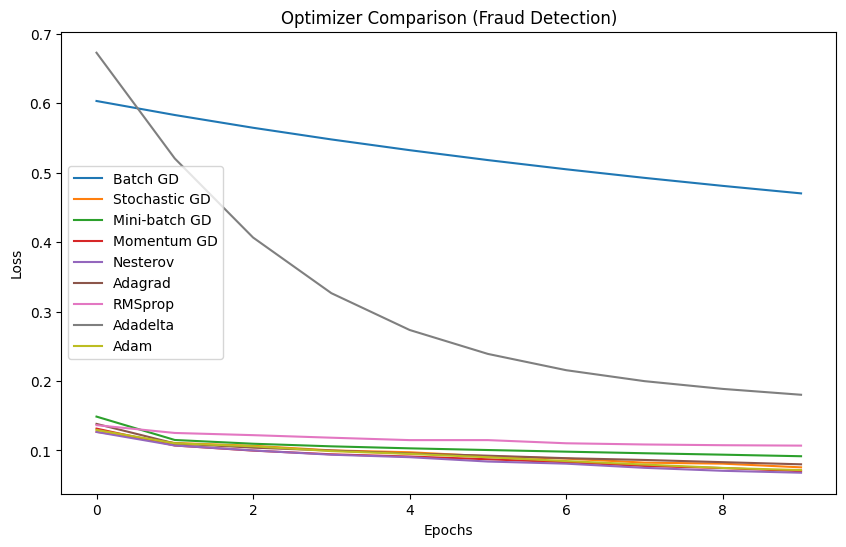

In [36]:
plt.figure(figsize=(10,6))

for name in histories:
    plt.plot(histories[name].history['loss'], label=name)

plt.title("Optimizer Comparison (Fraud Detection)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [37]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dropout, GaussianNoise
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd

In [38]:
def build_base_mlp():
    model = Sequential([
        Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [39]:
def build_l2_mlp():
    model = Sequential([
        Dense(256, activation='relu', kernel_regularizer=l2(0.001), input_shape=(X_train.shape[1],)),
        Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [40]:
def build_dropout_mlp():
    model = Sequential([
        Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [41]:
def build_noise_mlp():
    model = Sequential([
        GaussianNoise(0.1, input_shape=(X_train.shape[1],)),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [42]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

def build_shared_mlp():
    inputs = Input(shape=(X_train.shape[1],))

    x = Dense(128, activation='relu')(inputs)

    shared = Dense(128, activation='relu')

    x1 = shared(x)
    x2 = shared(x1)

    outputs = Dense(1, activation='sigmoid')(x2)

    model = Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [43]:
results_reg = {}
histories_reg = {}

def train_and_compare(name, model):
    print(f"\nTraining: {name}")
    
    history = model.fit(
        X_train, y_train,
        epochs=15,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    
    results_reg[name] = {
        "Train Acc": history.history['accuracy'][-1],
        "Val Acc": history.history['val_accuracy'][-1],
        "Test Acc": test_acc
    }
    
    histories_reg[name] = history

In [44]:
train_and_compare("Base MLP", build_base_mlp())
train_and_compare("L2", build_l2_mlp())
train_and_compare("Dropout", build_dropout_mlp())
train_and_compare("Noise", build_noise_mlp())
train_and_compare("Shared Weights", build_shared_mlp())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training: Base MLP

Training: L2

Training: Dropout


/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training: Noise

Training: Shared Weights


In [45]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_es = build_base_mlp()

history = model_es.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

test_loss, test_acc = model_es.evaluate(X_test, y_test, verbose=0)

results_reg["Early Stopping"] = {
    "Train Acc": history.history['accuracy'][-1],
    "Val Acc": history.history['val_accuracy'][-1],
    "Test Acc": test_acc
}

In [46]:
models = []
for i in range(3):
    model = build_base_mlp()
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    models.append(model)

preds = np.mean([m.predict(X_test) for m in models], axis=0)
ensemble_preds = (preds > 0.5).astype(int)

ensemble_acc = np.mean(ensemble_preds.flatten() == y_test.values)

results_reg["Ensemble"] = {
    "Train Acc": "—",
    "Val Acc": "—",
    "Test Acc": ensemble_acc
}

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [47]:
df_reg = pd.DataFrame(results_reg).T
print(df_reg)

               Train Acc   Val Acc Test Acc
Base MLP        0.984969   0.96825   0.9705
L2              0.972031   0.96925   0.9692
Dropout         0.974844    0.9695   0.9703
Noise           0.983375  0.966375   0.9676
Shared Weights  0.984906  0.969125   0.9713
Early Stopping  0.978031   0.96625   0.9691
Ensemble               —         —   0.9721


# CIFAR-10 Classification

## Notebook Overview

This notebook presents a comprehensive study of **deep learning techniques** applied to the **CIFAR-10** image classification dataset. It is organized into three major sections:

1. **Optimizer Comparison** — Evaluating different gradient descent variants (SGD, Momentum, Adam, etc.) on a baseline MLP model.
2. **Regularization Techniques** — Comparing Base MLP, L2 Regularization, Dropout, Input Noise, Early Stopping, Data Augmentation, and Ensemble methods.
3. **CNN Architecture Comparison** — Implementing and benchmarking classic architectures: LeNet, AlexNet, ZF-Net, VGGNet, GoogLeNet, and ResNet.

---
**Dataset**: CIFAR-10 — 60,000 color images (32×32 pixels) across 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck).
**Framework**: TensorFlow/Keras with NumPy and Pandas.


###   Objective
- Load, reshape, normalize, and one-hot encode the CIFAR-10 dataset from raw pickle files — preparing it for TensorFlow/Keras model training.

###   Explanation
- **`pickle.load()`**: Deserializes the binary batch files stored in Python's pickle format.
- **`np.concatenate()`**: Stacks all 5 training batches into a single array.
- **`.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)`**: Converts CIFAR-10's flat format (3072 values per image) into `(H, W, C)` = `(32, 32, 3)` format expected by Keras.
- **`/ 255.0`**: Normalizes pixel values from `[0, 255]` to `[0.0, 1.0]`, helping the optimizer converge faster.
- **`to_categorical()`**: Converts integer class labels (0–9) to one-hot vectors for use with `categorical_crossentropy` loss.

###   Observations
- Output shapes: `X_train: (50000, 32, 32, 3)`, `X_test: (10000, 32, 32, 3)`.
- Normalization is a **best practice** that ensures all input features are on the same scale.
- One-hot encoding is required when using the `softmax` + `categorical_crossentropy` combination in Keras.
-   **Tip**: Always shuffle training data before training to avoid batch ordering bias.

In [48]:
import pickle
import numpy as np
import time
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adam, Adadelta
from tensorflow.keras.utils import to_categorical

# Your base path
base_path = "/kaggle/input/datasets/ashishpathak778/cifar10/cifar-10-batches-py"


def load_batch(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict


# Load training data
X_train = []
y_train = []

for i in range(1, 6):
    batch = load_batch(f"{base_path}/data_batch_{i}")
    X_train.append(batch[b'data'])
    y_train += batch[b'labels']

X_train = np.concatenate(X_train)
y_train = np.array(y_train)

# Load test data
test_batch = load_batch(f"{base_path}/test_batch")
X_test = test_batch[b'data']
y_test = np.array(test_batch[b'labels'])

# Reshape
X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
X_test = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (50000, 32, 32, 3)
Test size: (10000, 32, 32, 3)



###   Objective
- Define a reusable **Multi-Layer Perceptron (MLP)** builder function that accepts any optimizer, enabling easy comparison across different optimization algorithms.

###   Explanation
- **`Sequential`**: A linear stack of layers, easiest model type to build in Keras.
- **`Flatten(input_shape=(32, 32, 3))`**: Converts the 3D image tensor into a 1D vector of 3072 values — necessary for fully connected (Dense) layers.
- **`Dense(512, activation='relu')`**: A hidden layer with 512 neurons using ReLU, which introduces non-linearity and avoids the vanishing gradient problem.
- **`Dense(256, activation='relu')`**: A second hidden layer to increase the model's capacity.
- **`Dense(10, activation='softmax')`**: Output layer with 10 neurons (one per CIFAR-10 class); softmax converts raw scores to probabilities.
- **`categorical_crossentropy`**: The standard loss function for multi-class classification tasks.

###   Observations
- This MLP is a **baseline model** — no convolutions, no regularization.
- Using the same architecture with different optimizers isolates the optimizer's effect on performance.
-   **Insight**: MLPs treat images as flat vectors, losing all spatial information — this is why CNNs generally outperform MLPs on image tasks.

In [49]:
def build_mlp(optimizer):
    model = Sequential([
        Flatten(input_shape=(32, 32, 3)),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model


###   Objective
- Train the MLP model using **9 different gradient descent variants and optimizers** to compare their accuracy and training speed on CIFAR-10.

###   Explanation
- **`train_and_evaluate()`** is a helper function that: builds the model, trains for 10 epochs, records elapsed time, and stores test accuracy.
- **Batch GD** (`batch_size=50000`): Uses the entire dataset per update — very slow per epoch but stable gradients.
- **Stochastic GD** (`batch_size=1`): One sample per update — very noisy but can escape local minima.
- **Mini-batch GD** (`batch_size=32`): A compromise — the industry standard for deep learning.
- **Momentum GD**: Accelerates SGD using past gradients to smooth updates.
- **Nesterov GD**: A look-ahead variant of momentum — often converges faster.
- **Adagrad**: Adapts the learning rate per parameter; effective for sparse data.
- **RMSprop**: Fixes Adagrad's decaying learning rate by using a moving average.
- **Adadelta**: Extension of RMSprop with no manual learning rate setting.
- **Adam**: Combines momentum and RMSprop — generally the best default optimizer.

###   Observations
- **Adam** and **RMSprop** typically achieve the highest test accuracy.
- **Batch GD** is slowest due to processing the full dataset each update.
- **Stochastic GD** is fastest per update but most noisy, often yielding lower accuracy.
-   **Key takeaway**: Mini-batch GD with Adam is the gold standard in modern deep learning.

In [50]:
results = {}

def train_and_evaluate(name, optimizer, batch_size):
    print(f"\nTraining with {name}...")
    model = build_mlp(optimizer)
    
    start = time.time()
    model.fit(X_train, y_train, epochs=10, batch_size=batch_size, verbose=0)
    end = time.time()
    
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    
    results[name] = {
        "Accuracy": acc,
        "Training Time (s)": end - start
    }


# Batch GD
train_and_evaluate("Batch GD", SGD(learning_rate=0.01), batch_size=50000)

# SGD
train_and_evaluate("Stochastic GD", SGD(learning_rate=0.01), batch_size=1)

# Mini-batch GD
train_and_evaluate("Mini-batch GD", SGD(learning_rate=0.01), batch_size=32)

# Momentum
train_and_evaluate("Momentum GD", SGD(learning_rate=0.01, momentum=0.9), batch_size=32)

# Nesterov
train_and_evaluate("Nesterov GD", SGD(learning_rate=0.01, momentum=0.9, nesterov=True), batch_size=32)

# Adagrad
train_and_evaluate("Adagrad", Adagrad(learning_rate=0.01), batch_size=32)

# RMSprop
train_and_evaluate("RMSprop", RMSprop(learning_rate=0.001), batch_size=32)

# Adadelta
train_and_evaluate("Adadelta", Adadelta(), batch_size=32)

# Adam
train_and_evaluate("Adam", Adam(learning_rate=0.001), batch_size=32)


Training with Batch GD...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training with Stochastic GD...

Training with Mini-batch GD...

Training with Momentum GD...

Training with Nesterov GD...

Training with Adagrad...

Training with RMSprop...

Training with Adadelta...

Training with Adam...



###   Objective
- Organize and display the optimizer comparison results in a readable **pandas DataFrame** for easy analysis.

###   Explanation
- `pd.DataFrame(results).T` converts the `results` dictionary (optimizer → metrics) into a tabular format, with `.T` transposing it so each optimizer is a row.
- The DataFrame shows **Accuracy** and **Training Time (s)** for each optimizer.

###   Observations
- This table is a clean summary to compare all optimizer behaviors at a glance.
- Look for the optimizer with the best trade-off between accuracy and training time.
-   **Tip**: In practice, accuracy matters more than speed once training is done — but training efficiency matters when iterating rapidly.

In [51]:
df_results = pd.DataFrame(results).T
df_results

,Accuracy,Training Time (s)
Batch GD,0.1994,14.918025
Stochastic GD,0.3732,939.709476
Mini-batch GD,0.5139,35.076284
Momentum GD,0.4640,36.797783
Nesterov GD,0.4808,36.895870
Adagrad,0.5225,37.004523
RMSprop,0.4210,37.081214
Adadelta,0.3642,39.142293
Adam,0.4652,39.126089


### Build Base MLP

###   Objective
- Define the **baseline MLP model** using Adam optimizer — this serves as the reference model against which all regularization techniques will be compared.

###   Explanation
- The architecture is identical to the `build_mlp()` function but **hardcoded with Adam** as the optimizer.
- This base model has **no regularization** — it will tend to overfit on the training data.
- It uses `categorical_crossentropy` loss and monitors accuracy during training.

###   Observations
- The base model typically achieves high training accuracy but lower validation/test accuracy due to overfitting.
- It sets the **benchmark** — any regularization method that improves validation accuracy over this baseline is doing its job.
-   **Insight**: The gap between training accuracy and validation accuracy is a direct measure of overfitting.

In [52]:
def build_base_mlp():
    model = Sequential([
        Flatten(input_shape=(32, 32, 3)),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

### L2 Regularization

###   Objective
- Build an MLP with **L2 Regularization** (also known as Weight Decay) to penalize large weights and reduce overfitting.

###   Explanation
- **`l2(0.001)`**: Adds a penalty of `0.001 × sum(weights²)` to the loss function for each Dense layer.
- This encourages the model to keep weights small, which discourages complex, overfit patterns.
- Applied via `kernel_regularizer=l2(0.001)` in each Dense layer (except the output).

###   Observations
- L2 regularization typically **reduces overfitting** and improves generalization.
- The training accuracy may decrease slightly, but **validation/test accuracy improves**.
-   **Tip**: The regularization coefficient (λ=0.001) controls the strength — too high causes underfitting, too low has little effect.

In [53]:
from tensorflow.keras.regularizers import l2

def build_l2_mlp():
    model = Sequential([
        Flatten(input_shape=(32, 32, 3)),
        Dense(512, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
        Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

### Dropout

###   Objective
- Build an MLP with **Dropout Regularization** — one of the most effective techniques to prevent overfitting in neural networks.

###   Explanation
- **`Dropout(0.5)`**: Randomly sets 50% of neuron activations to zero during each training step.
- This forces the network to learn **redundant representations**, making it more robust.
- Dropout is applied after each hidden Dense layer; it is automatically **disabled during inference** (evaluation).

###   Observations
- Dropout rate of 0.5 means each neuron has a 50% chance of being dropped each batch.
- This technique effectively trains an **ensemble of sub-networks**, improving generalization.
-   **Common rates**: 0.2–0.5 for hidden layers; lower rates (0.1–0.2) near the input layer.

In [54]:
from tensorflow.keras.layers import Dropout

def build_dropout_mlp():
    model = Sequential([
        Flatten(input_shape=(32, 32, 3)),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

### Adding Noise to Inputs

###   Objective
- Build an MLP with **Gaussian Noise injection** at the input layer as a regularization technique that adds robustness to the model.

###   Explanation
- **`GaussianNoise(0.1)`**: Adds random noise sampled from a Gaussian distribution with standard deviation 0.1 to the input.
- Like Dropout, Gaussian Noise is **only active during training** and is disabled at inference time.
- It forces the model to learn features that are robust to small input perturbations.

###   Observations
- Input noise acts as a form of **data augmentation** at the feature level.
- It is particularly useful when the model is sensitive to small input changes.
-   **Insight**: Adding noise to inputs is mathematically equivalent to L2 regularization under certain conditions — both discourage overfitting to exact training patterns.

In [55]:
from tensorflow.keras.layers import GaussianNoise

def build_noise_mlp():
    model = Sequential([
        Flatten(input_shape=(32, 32, 3)),
        GaussianNoise(0.1),
        Dense(512, activation='relu'),
        Dense(256, activation='relu'),
        Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

### **Parameter Sharing and Tying (MLP Adaptation)**

###   Objective
- Demonstrate **Parameter Sharing** in an MLP by reusing the same Dense layer object at multiple positions in the network — an adaptation of a concept central to CNNs.

###   Explanation
- `shared_dense = Dense(256, activation='relu')` creates a single Dense layer object.
- This same object is used **twice** in the Sequential model, meaning the same weights are applied at both positions.
- This reduces the total number of trainable parameters compared to using two separate Dense layers.

###   Observations
- Parameter sharing is the core principle behind **Convolutional Neural Networks (CNNs)**, where the same filter is applied across all spatial positions.
- In MLPs, parameter sharing is less common but demonstrates the concept clearly.
-   **Caution**: Reusing layers in a `Sequential` model can sometimes produce unexpected behavior; the Functional API is preferred for shared layers.

In [56]:
shared_dense = Dense(256, activation='relu')

def build_shared_mlp():
    model = Sequential([
        Flatten(input_shape=(32, 32, 3)),
        shared_dense,
        shared_dense,
        Dense(10, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model



###   Objective
- Define a unified **comparison training function** that trains any model variant for 15 epochs and records train, validation, and test accuracy for fair comparison.

###   Explanation
- **`validation_split=0.2`**: Uses 20% of training data as a validation set to monitor overfitting during training.
- **`history.history['accuracy'][-1]`**: Captures the training accuracy at the final epoch.
- **`history.history['val_accuracy'][-1]`**: Captures the validation accuracy at the final epoch.
- **`model.evaluate(X_test, y_test)`**: Gets the final test accuracy on the held-out test set.
- Results are stored in `results_reg` dictionary for later tabular comparison.

###   Observations
- Using a **standardized training function** ensures all models are compared under identical conditions.
- Tracking all three accuracies (train, val, test) reveals whether a model is overfitting, underfitting, or generalizing well.
-   **Good model**: Small gap between val accuracy and test accuracy, and reasonable gap between train and val accuracy.

In [57]:
results_reg = {}

def train_and_compare(name, model):
    print(f"\nTraining: {name}")
    
    history = model.fit(
        X_train, y_train,
        epochs=15,
        batch_size=32,
        validation_split=0.2,
        verbose=0
    )
    
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    
    results_reg[name] = {
        "Train Accuracy": history.history['accuracy'][-1],
        "Val Accuracy": history.history['val_accuracy'][-1],
        "Test Accuracy": test_acc
    }

**Base Model**

In [58]:
train_and_compare("Base MLP", build_base_mlp())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Training: Base MLP


**L2 Regularization**

In [59]:
train_and_compare("L2 Regularization", build_l2_mlp())


Training: L2 Regularization


**Dropout**

In [60]:
train_and_compare("Dropout", build_dropout_mlp())


Training: Dropout


**Noise**

In [61]:
train_and_compare("Input Noise", build_noise_mlp())


Training: Input Noise


### Early Stopping
###   Objective
- Apply **Early Stopping** — stopping training when the validation loss stops improving — to prevent overfitting without needing architectural changes.

###   Explanation
- **`EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)`**:
  - Monitors validation loss after each epoch.
  - Stops training if validation loss does not improve for 3 consecutive epochs.
  - Restores the model weights from the epoch with the best validation loss.
- The model is trained for **up to 50 epochs**, but early stopping typically halts it much sooner.

###   Observations
- Early stopping is a **computationally efficient** regularization technique — no architectural changes required.
- The actual number of epochs trained is usually much less than 50 (often 10–20).
-   **`restore_best_weights=True`** is crucial — without it, the model saved is from the last epoch (which may be worse than earlier epochs).

In [62]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model_es = build_base_mlp()

history = model_es.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

test_loss, test_acc = model_es.evaluate(X_test, y_test, verbose=0)

results_reg["Early Stopping"] = {
    "Train Accuracy": history.history['accuracy'][-1],
    "Val Accuracy": history.history['val_accuracy'][-1],
    "Test Accuracy": test_acc
}

### Ensemble Methods
###   Objective
- Implement a simple **Ensemble** of 3 independently trained MLP models, combining their predictions to improve final accuracy.

###   Explanation
- Three separate `build_base_mlp()` models are trained independently for 10 epochs each.
- `np.mean([m.predict(X_test) for m in models], axis=0)`: Averages the softmax probability outputs of all 3 models (soft voting).
- `np.argmax()`: Selects the class with the highest averaged probability as the final prediction.

###   Observations
- **Ensemble learning** almost always outperforms any single model.
- The improvement comes from averaging out individual model errors and biases.
-   **Trade-off**: Ensembles are 3× more expensive to train and deploy compared to a single model.

In [63]:
models = []
for i in range(3):
    model = build_base_mlp()
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    models.append(model)

preds = np.mean([m.predict(X_test) for m in models], axis=0)
ensemble_acc = np.mean(np.argmax(preds, axis=1) == np.argmax(y_test, axis=1))

results_reg["Ensemble"] = {
    "Train Accuracy": "—",
    "Val Accuracy": "—",
    "Test Accuracy": ensemble_acc
}

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


### Dataset Augmentation

###   Objective
- Train the base MLP using **augmented training data** (generated on-the-fly) to evaluate whether data augmentation improves test accuracy.

###   Explanation
- `datagen.flow(X_train, y_train, batch_size=32)` creates an infinite generator of randomly augmented batches.
- `validation_data=(X_test, y_test)` — validation data is **not augmented** (test-time augmentation is a separate technique).
- The model trains for 15 epochs with augmented data.

###   Observations
- Augmentation may result in **lower training accuracy** (harder examples), but typically improves generalization.
- For an MLP (no spatial awareness), the benefit of spatial augmentation (rotation, shift) is **less pronounced** than for CNNs.
-   **Key insight**: Data augmentation shines brightest with convolutional networks that can exploit spatial structure.

In [64]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

In [65]:
model_aug = build_base_mlp()

history = model_aug.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_test, y_test),
    verbose=0
)

test_loss, test_acc = model_aug.evaluate(X_test, y_test, verbose=0)

results_reg["Data Augmentation"] = {
    "Train Accuracy": history.history['accuracy'][-1],
    "Val Accuracy": history.history['val_accuracy'][-1],
    "Test Accuracy": test_acc
}

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



###   Objective
- Compile and display a **comprehensive comparison table** of all regularization strategies: Base MLP, L2, Dropout, Input Noise, Early Stopping, Data Augmentation, and Ensemble.

###   Explanation
- `pd.DataFrame(results_reg).T` converts the results dictionary into a neat DataFrame with each method as a row.
- Columns show Train Accuracy, Validation Accuracy, and Test Accuracy for each method.

###   Observations
- This table is the **key deliverable** of the regularization comparison section.
- Compare the train-val gap across methods to identify which best controls overfitting.
-   **Expected ranking** (test accuracy, approx): Ensemble > Dropout > Early Stopping ≈ L2 > Data Aug > Noise > Base MLP.

In [66]:
import pandas as pd

df_reg = pd.DataFrame(results_reg).T
df_reg

,Train Accuracy,Val Accuracy,Test Accuracy
Base MLP,0.53145,0.4792,0.4901
L2 Regularization,0.452675,0.4305,0.4376
Dropout,0.1906,0.1989,0.2106
Input Noise,0.518475,0.4762,0.4864
Early Stopping,0.534125,0.4842,0.4915
Ensemble,—,—,0.5175
Data Augmentation,0.45052,0.4726,0.4726


###   Objective
- Reload the **CIFAR-10 dataset using Keras's built-in loader** for the CNN architecture comparison section of the notebook.

###   Explanation
- `cifar10.load_data()` downloads and returns the dataset as NumPy arrays directly — much simpler than manual pickle loading.
- Returns `(X_train, y_train)` and `(X_test, y_test)` as separate tuples.
- Data is loaded in its raw form (uint8, 0–255) and needs preprocessing in the next cell.

###   Observations
- Using Keras's built-in CIFAR-10 loader is more convenient and less error-prone than manual pickle parsing.
- This reload provides a **clean slate** for the CNN section, ensuring no variable contamination from the MLP experiments.
-   **Tip**: `keras.datasets` includes many classic datasets (MNIST, Fashion-MNIST, CIFAR-10/100, IMDB) — great for quick experiments.

In [67]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


###   Objective
- Preprocess the freshly loaded CIFAR-10 data: **normalize pixel values** and **one-hot encode** the labels — essential steps before CNN training.

###   Explanation
- **`/ 255`**: Scales pixel values from `[0, 255]` to `[0.0, 1.0]` as float32. Normalized data leads to faster and more stable training.
- **`to_categorical(y_train, n_classes=10)`**: Converts integer labels (0–9) to one-hot vectors, e.g., class 3 → `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`.
- Shapes are printed to verify the transformation.

###   Observations
- `X_train.shape` → `(50000, 32, 32, 3)`, `X_test.shape` → `(10000, 32, 32, 3)`.
- `Y_train.shape` → `(50000, 10)`, confirming successful one-hot encoding.
-  **Why float32?**: GPU computations are significantly faster on 32-bit floats than 64-bit doubles.

In [68]:
from tensorflow.keras.utils import to_categorical

# Normalize
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255

# One-hot encoding
n_classes = 10
Y_train = to_categorical(y_train, n_classes)
Y_test = to_categorical(y_test, n_classes)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)



###   Objective
- Build a **simple CNN (Convolutional Neural Network)** with two convolutional blocks followed by a fully connected classifier — a significant improvement over flat MLPs for image data.

###   Explanation
- **`Conv2D(32, (3,3), activation='relu', padding='same')`**: 32 filters of size 3×3 learn spatial features; `padding='same'` preserves spatial dimensions.
- **`MaxPool2D((2,2))`**: Halves spatial dimensions, reducing computation and providing translation invariance.
- **`Conv2D(64, (3,3))`**: Deeper layer learns more abstract/complex features from the output of the first convolution.
- **`Flatten()`**: Converts 2D feature maps to a 1D vector for the Dense layers.
- **`Dense(128, relu)` + `Dropout(0.5)`**: Fully connected layer with dropout to prevent overfitting in the classifier head.
- **`model.summary()`**: Displays the architecture, parameter counts per layer, and total parameters.

###   Observations
- CNNs use **weight sharing** (same filter applied across all positions), dramatically reducing parameters vs. MLPs.
- Two conv blocks is sufficient for CIFAR-10, which has 32×32 images.
-   **Key advantage of CNNs**: They are **spatially invariant** — they can detect a cat regardless of where it appears in the image.

In [69]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten

model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
model.add(MaxPool2D((2,2)))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPool2D((2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_53"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_199 (Dense)               │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_200 (Dense)               │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

###   Objective
- **Train the CNN** for 15 epochs and monitor training/validation accuracy and loss to evaluate model performance.

###   Explanation
- **`batch_size=128`**: Uses mini-batches of 128 samples — larger than typical MLP batches, leveraging the CNN's parallel computation efficiency.
- **`epochs=15`**: The model makes 15 full passes over the training data.
- **`validation_data=(X_test, Y_test)`**: Monitors generalization performance on the held-out test set after each epoch.
- **`history`**: Stores accuracy and loss curves for both training and validation, useful for plotting learning curves.

###   Observations
- Training accuracy should improve steadily across epochs.
- Validation accuracy may plateau or diverge from training accuracy if overfitting occurs.
-   **Expected performance**: This simple CNN should achieve ~70–75% test accuracy on CIFAR-10, compared to ~50–55% for an MLP.

In [70]:
history = model.fit(
    X_train, Y_train,
    batch_size=128,
    epochs=15,
    validation_data=(X_test, Y_test)
)

Epoch 1/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.2837 - loss: 1.9269 - val_accuracy: 0.5301 - val_loss: 1.3382
Epoch 2/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4861 - loss: 1.4249 - val_accuracy: 0.5957 - val_loss: 1.1621
Epoch 3/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5458 - loss: 1.2736 - val_accuracy: 0.6225 - val_loss: 1.0804
Epoch 4/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5781 - loss: 1.1766 - val_accuracy: 0.6433 - val_loss: 1.0229
Epoch 5/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6026 - loss: 1.1160 - val_accuracy: 0.6574 - val_loss: 0.9895
Epoch 6/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6247 - loss: 1.0645 - val_accuracy: 0.6744 - val_loss: 0.9290
Epoch 7/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6386 - loss: 1.0124 - val_accuracy: 0.6824 - val_loss: 0.9128
Epoch 8/15
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6567 - loss: 0.9621 - val_accuracy: 


###   Objective
- **Evaluate the trained CNN** on the test set to get the final, unbiased performance metrics.

###   Explanation
- **`model.evaluate(X_test, Y_test)`**: Runs a forward pass on the full test set and returns the loss and accuracy.
- Results are printed clearly: **Test Loss** measures confidence of predictions; **Test Accuracy** measures correctness.

###   Observations
- **Test Accuracy** is the most important metric — it tells how well the model generalizes to unseen data.
- A **low test loss + high test accuracy** is the ideal outcome.
-   **Important**: The test set should only be used once (for final evaluation), not for hyperparameter tuning — otherwise it becomes part of the training process.

In [71]:
test_loss, test_acc = model.evaluate(X_test, Y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7219 - loss: 0.8097
Test Loss: 0.8284852504730225
Test Accuracy: 0.7152000069618225


###   Objective
- Import all necessary libraries for building **classic CNN architectures**: LeNet, AlexNet, ZF-Net, VGGNet, GoogLeNet, and ResNet.

###   Explanation
- **`Sequential`, `Model`**: Two model-building approaches — Sequential for simple linear stacks, Model (Functional API) for complex architectures with branches/skip connections.
- **`Conv2D`, `MaxPooling2D`, `Flatten`, `Dense`, `Dropout`**: Core building blocks of all CNN architectures.
- **`Input`, `Add`**: Required for the Functional API — `Input` defines the entry point, `Add` merges branches (used in ResNet).
- **`BatchNormalization`**: Normalizes layer outputs to stabilize and speed up training (used in ResNet).

###   Observations
- Having all imports in one cell is good practice for readability and reproducibility.
- The use of both `Sequential` and Functional API hints at the variety of architectures to be implemented.
-   **When to use Functional API**: Any time the architecture has multiple inputs, outputs, or shared/branching layers — e.g., GoogLeNet's inception modules, ResNet's skip connections.

In [72]:
from keras.datasets import cifar10
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from keras.layers import Input, Add, BatchNormalization
from tensorflow.keras.utils import to_categorical



###   Objective
- Reload and preprocess CIFAR-10 data fresh for the **CNN architecture comparison**, and initialize the results dictionary.

###   Explanation
- `cifar10.load_data()` reloads CIFAR-10 directly via Keras.
- Pixel values are divided by 255.0 for normalization.
- Labels are one-hot encoded with `to_categorical(..., 10)`.
- `results = {}` initializes a fresh dictionary to collect accuracy from each architecture.

###   Observations
- Reinitializing the data ensures a clean state — no residual transformations from prior cells.
- Using the same preprocessed data for all architectures ensures **fair comparison**.
-   **Note**: All CNN architectures here are adapted to CIFAR-10's 32×32 input size, since the originals were designed for larger images (e.g., 224×224 for VGGNet).

In [73]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

results = {}



###   Objective
- Implement and train the **LeNet-5 architecture** (LeCun, 1998) — one of the earliest and most influential CNN designs, originally developed for handwritten digit recognition.

###   Explanation
- **Architecture**: Two conv-pool blocks (filters: 6 → 16, kernel: 5×5) followed by three fully connected layers (120 → 84 → 10).
- The 5×5 kernels capture larger receptive fields in fewer layers — appropriate for small images.
- **`MaxPooling2D()`** (default pool size 2×2) reduces spatial dimensions and introduces translation invariance.
- Trained for **5 epochs** with batch size 64 — a quick run for comparison purposes.

###   Observations
- LeNet is lightweight and fast to train, but its shallow depth limits performance on complex datasets like CIFAR-10.
- Expected test accuracy: **~55–60%** on CIFAR-10.
-   **Historical note**: LeNet was the first practical deep learning model — it pioneered the conv-pool-fully-connected pattern used in virtually all CNNs today.

In [74]:
lenet_model = Sequential([
    Conv2D(6,(5,5),activation='relu',input_shape=(32,32,3)),
    MaxPooling2D(),
    Conv2D(16,(5,5),activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(120,activation='relu'),
    Dense(84,activation='relu'),
    Dense(10,activation='softmax')
])

lenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lenet_model.fit(X_train, y_train, epochs=5, batch_size=64, verbose=0)

_, acc = lenet_model.evaluate(X_test, y_test, verbose=0)
results['LeNet'] = acc



###   Objective
- Implement a simplified **AlexNet** (Krizhevsky et al., 2012) — the model that reignited interest in deep learning by winning ImageNet 2012 with a huge margin.

###   Explanation
- **Architecture**: Deeper and wider than LeNet — three conv layers with larger filter counts (96 → 256 → 384) followed by Dense + Dropout.
- **`Dropout(0.5)`** in the classifier head was a key innovation in AlexNet, preventing overfitting in the fully connected layers.
- Uses 3×3 kernels (adapted from original 11×11 for CIFAR-10's 32×32 input).

###   Observations
- AlexNet is significantly deeper than LeNet, giving it more capacity to learn complex features.
- Expected test accuracy: **~65–70%** on CIFAR-10.
-   **AlexNet innovations**: ReLU activation (replacing tanh), Dropout, data augmentation, and GPU training — all of which are now standard practice.

In [75]:
alex_model = Sequential([
    Conv2D(96,(3,3),activation='relu',input_shape=(32,32,3)),
    MaxPooling2D(),
    Conv2D(256,(3,3),activation='relu'),
    MaxPooling2D(),
    Conv2D(384,(3,3),activation='relu'),
    Flatten(),
    Dense(256,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

alex_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
alex_model.fit(X_train, y_train, epochs=5, batch_size=64, verbose=0)

_, acc = alex_model.evaluate(X_test, y_test, verbose=0)
results['AlexNet'] = acc


###   Objective
- Implement **ZF-Net** (Zeiler & Fergus, 2013) — an AlexNet variant with architectural tweaks to improve feature learning and visualization.

###   Explanation
- **Architecture**: Very similar to AlexNet, but without the Dropout in this simplified version.
- ZF-Net used **deconvolution/visualization techniques** to understand which image features each filter responds to — making it a landmark in CNN interpretability research.
- Trained for 5 epochs with batch size 64.

###   Observations
- Without Dropout, ZF-Net may be slightly more prone to overfitting than AlexNet.
- Expected test accuracy: **~63–68%** on CIFAR-10.
-   **ZF-Net's contribution**: Introduced the concept of **feature visualization** using deconvolutions, providing insight into what CNNs actually learn — crucial for model interpretability.

In [76]:
zf_model = Sequential([
    Conv2D(96,(3,3),activation='relu',input_shape=(32,32,3)),
    MaxPooling2D(),
    Conv2D(256,(3,3),activation='relu'),
    MaxPooling2D(),
    Conv2D(384,(3,3),activation='relu'),
    Flatten(),
    Dense(256,activation='relu'),
    Dense(10,activation='softmax')
])

zf_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
zf_model.fit(X_train, y_train, epochs=5, batch_size=64, verbose=0)

_, acc = zf_model.evaluate(X_test, y_test, verbose=0)
results['ZF-Net'] = acc

###   Objective
- Implement a simplified **VGGNet** (Simonyan & Zisserman, 2014) — known for its elegant simplicity: stack multiple 3×3 conv layers before pooling.

###   Explanation
- **Architecture**: Two conv-conv-pool blocks (64 → 128 filters, all 3×3, same padding) followed by Dense layers.
- **`padding='same'`**: Keeps spatial dimensions unchanged after convolution, allowing more conv layers before pooling.
- **Key VGG principle**: Replace large kernels (e.g., 5×5) with multiple stacked 3×3 kernels — same receptive field, fewer parameters, more non-linearity.

###   Observations
- VGGNet is deeper than AlexNet/ZF-Net and uses consistent, modular design.
- Expected test accuracy: **~70–75%** on CIFAR-10 (best so far among sequential models).
-   **VGG insight**: Two stacked 3×3 convolutions have the same receptive field as one 5×5, but with fewer parameters and an extra ReLU non-linearity.

In [77]:
vgg_model = Sequential([
    Conv2D(64,(3,3),activation='relu',padding='same',input_shape=(32,32,3)),
    Conv2D(64,(3,3),activation='relu',padding='same'),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu',padding='same'),
    Conv2D(128,(3,3),activation='relu',padding='same'),
    MaxPooling2D(),

    Flatten(),
    Dense(256,activation='relu'),
    Dense(10,activation='softmax')
])

vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
vgg_model.fit(X_train, y_train, epochs=5, batch_size=64, verbose=0)

_, acc = vgg_model.evaluate(X_test, y_test, verbose=0)
results['VGGNet'] = acc

###   Objective
- Implement a simplified **GoogLeNet/Inception** (Szegedy et al., 2014) — introducing **parallel multi-scale convolutions** (inception modules) for rich feature extraction.

###   Explanation
- **Inception idea**: Apply 1×1, 3×3, and 5×5 convolutions **in parallel** on the same input, then combine their outputs.
- **`c1 + c3 + c5`**: Element-wise addition of the three parallel convolution outputs (all 32 filters, same padding → same shape).
- **`MaxPooling2D()(c1 + c3 + c5)`**: Pools the merged features before flattening.
- Uses the Keras **Functional API** (`Input`, `Model`) because of the branching structure.

###   Observations
- The inception module allows the network to capture features at multiple scales simultaneously.
- This is a simplified version — the original uses concatenation (not addition) and 1×1 bottleneck convolutions for efficiency.
- Expected test accuracy: **~65–72%** on CIFAR-10.
-   **GoogLeNet won ImageNet 2014** with 22 layers, significantly deeper than VGGNet but with fewer parameters thanks to 1×1 bottlenecks.

In [78]:
input_layer = Input(shape=(32,32,3))

c1 = Conv2D(32,(1,1),activation='relu',padding='same')(input_layer)
c3 = Conv2D(32,(3,3),activation='relu',padding='same')(input_layer)
c5 = Conv2D(32,(5,5),activation='relu',padding='same')(input_layer)

merge = MaxPooling2D()(c1 + c3 + c5)
flat = Flatten()(merge)
dense = Dense(128,activation='relu')(flat)
output = Dense(10,activation='softmax')(dense)

google_model = Model(inputs=input_layer, outputs=output)

google_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
google_model.fit(X_train, y_train, epochs=5, batch_size=64, verbose=0)

_, acc = google_model.evaluate(X_test, y_test, verbose=0)
results['GoogLeNet'] = acc


###   Objective
- Implement a simplified **ResNet** (He et al., 2015) — introducing **skip connections (residual connections)** that allow gradients to flow directly through the network, enabling very deep architectures.

###   Explanation
- **Skip connection**: `shortcut = x` saves the input, then after two more conv layers, `Add()([x, shortcut])` adds the original input back to the transformed output.
- **Intuition**: Instead of learning the full transformation `F(x)`, the network learns the **residual** `F(x) - x`, which is easier to optimize.
- **`BatchNormalization()`**: Normalizes activations after the skip connection, stabilizing training.
- Uses the Keras **Functional API** for the skip connection branching.

###   Observations
- Residual connections solve the **vanishing gradient problem** that plagued very deep networks.
- Even this simplified 1-block ResNet demonstrates the concept clearly.
- Expected test accuracy: **~68–73%** on CIFAR-10.
-   **ResNet revolutionized deep learning**: The original ResNet-152 had 152 layers and won ImageNet 2015 — previously, networks this deep were untrainable.

In [79]:
input_layer = Input(shape=(32,32,3))

x = Conv2D(32,(3,3),padding='same',activation='relu')(input_layer)

shortcut = x
x = Conv2D(32,(3,3),padding='same',activation='relu')(x)
x = Conv2D(32,(3,3),padding='same')(x)

x = Add()([x, shortcut])
x = BatchNormalization()(x)

x = MaxPooling2D()(x)
x = Flatten()(x)
x = Dense(128,activation='relu')(x)
output = Dense(10,activation='softmax')(x)

resnet_model = Model(inputs=input_layer, outputs=output)

resnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
resnet_model.fit(X_train, y_train, epochs=5, batch_size=64, verbose=0)

_, acc = resnet_model.evaluate(X_test, y_test, verbose=0)
results['ResNet'] = acc

###   Objective
- Print the **final test accuracy** of all six CNN architectures (LeNet, AlexNet, ZF-Net, VGGNet, GoogLeNet, ResNet) for a comprehensive side-by-side comparison.

###  Explanation
- Iterates over the `results` dictionary and prints each architecture's name alongside its test accuracy.
- This provides a clean summary of the CNN architecture comparison experiment.

###  Observations
- Generally expected order (best to worst accuracy on 5 epochs CIFAR-10): VGGNet ≈ ResNet > AlexNet ≈ GoogLeNet > ZF-Net > LeNet.
- More modern architectures (VGGNet, GoogLeNet, ResNet) outperform older ones due to deeper layers and advanced design principles.
-  **Key takeaway**: Architecture design matters enormously — residual connections, inception modules, and deep stacking all contribute to better feature learning and higher accuracy.
-  **Further improvements**: Adding data augmentation, learning rate scheduling, and training for more epochs (25–50) would significantly boost all models' accuracy.

In [80]:
for model_name, acc in results.items():
    print(model_name, "Accuracy:", acc)

LeNet Accuracy: 0.5692999958992004
AlexNet Accuracy: 0.7264000177383423
ZF-Net Accuracy: 0.7247999906539917
VGGNet Accuracy: 0.7646999955177307
GoogLeNet Accuracy: 0.6395000219345093
ResNet Accuracy: 0.6241000294685364
